# 16. The projected density of states

Which atom, and which orbital, does a band belong to? The answer is the projection of every
Kohn-Sham state onto the pseudo-atomic orbitals the pseudopotential file already carries,
`|<phi_i|S|psi_nk>|^2` — Quantum ESPRESSO's `projwfc.x`. Summed against a delta it gives the
density of states resolved by atom, by `l` and by `m`; summed against the occupations it gives
the Löwdin charges.

Everything below is silicon with an ultrasoft dataset, and every number is compared with
`projwfc.x` run on the same input: the **projections agree to 5e-4** — which is all its
three-decimal printout allows — the **Löwdin charges to 5e-5**, and the curves to **0.3% of
their peak**.

Each Kohn-Sham state is resolved onto orbitals that are Löwdin-orthogonalised over
*every* atomic orbital in the crystal, which is what makes the weights sum to at most
one:

$$\rho_i(E) = \sum_{n\mathbf k} w_{\mathbf k}\,
   \big|\langle \tilde\phi_i | \hat S | \psi_{n\mathbf k}\rangle\big|^2\,
   \delta(E - \varepsilon_{n\mathbf k}),
\qquad
|\tilde\phi\rangle = O^{-1/2}\,\hat S\,|\phi\rangle,
\quad O_{ij} = \langle \phi_i | \hat S | \phi_j \rangle$$

$$\text{spilling} = 1 - \frac{1}{N_{\rm elec}} \sum_i \int^{E_F} \rho_i(E)\, dE$$

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pypresso import Calculator
from pypresso.io import read_pdos_file, read_projwfc_output
from pypresso.projwfc import atomic_projections
from pypresso.system.kpoints import KPoints
from pypresso.units import RY_TO_EV
from pypresso.workflows.nscf import fixed_density_states

CASES = Path("../tests/data/qe")
PSEUDO = Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si2-us-dense.in", pseudo_dir=PSEUDO,
                               announce=False, conv_thr=1e-10)
system, pseudos = silicon.system, silicon.pseudos
scf = silicon.get_scf()
print(f"silicon, ultrasoft: {system.kpoints.nk} irreducible k-points, "
      f"E = {scf.total_energy:.8f} Ry")

silicon, ultrasoft: 29 irreducible k-points, E = -22.76589933 Ry


## Running it

`run_pdos` takes the converged run itself, not just its density: what gets projected is the
*wavefunctions*. Nothing is re-diagonalised — `projwfc.x` reads the states `pw.x` left in its
output directory, and this does the same with the states in memory. (Passing `grid=` instead
re-solves the bands on a finer grid first, exactly as a `nscf` run would.)

The energy window is pinned to the reference file's so that the two curves are sampled at the
same energies; left alone, each code sizes its own grid from its own band extremes, which
differ in the fourth decimal of an eV.

In [2]:
reference = read_projwfc_output(CASES / "reference.projwfc.si2-us-dense")
energies_ev = read_pdos_file(CASES / "reference.si2-us-dense.pdos_tot")[0]

pdos = silicon.get_pdos(
    delta_e=0.05 / RY_TO_EV,   # projwfc.x's DeltaE and degauss for the committed run
    degauss=0.0147,            # 0.2 eV -- its degauss is in Ry, its DeltaE is not
    emin=energies_ev[0] / RY_TO_EV,
    emax=energies_ev[-1] / RY_TO_EV,
)

print(f"{len(pdos.channels)} atomic states: "
      + ", ".join(str(c) for c in pdos.channels[:4]) + ", ...")
print(f"projectors: {pdos.projectors}   scheme: {pdos.scheme}")
print()
print(pdos.charges.format(
    tuple(system.structure.species[t].name for t in system.structure.types)))

8 atomic states: #1 Si1 s, #2 Si1 pz, #3 Si1 px, #4 Si1 py, ...
projectors: ortho-atomic   scheme: gaussian

Lowdin Charges:

     Atom #   1 (Si): total charge =   3.9647
       s =   1.1596
       p =   2.8051, pz=  0.9350, px=  0.9350, py=  0.9350
     Atom #   2 (Si): total charge =   3.9647
       s =   1.1596
       p =   2.8051, pz=  0.9350, px=  0.9350, py=  0.9350
     Spilling Parameter:   0.0088


## Against `projwfc.x`

The Löwdin charges side by side. `projwfc.x` prints four decimals, and that is the limit of
the comparison rather than the limit of the agreement.

In [3]:
rows = []
for atom, printed in reference.charges.items():
    mine = pdos.charges.charges[atom - 1]
    rows.append((f"Si {atom} total", pdos.charges.total[atom - 1], printed["total"]))
    for l, letter in enumerate("spd"[: mine.size]):
        if letter in printed:
            rows.append((f"Si {atom}  {letter}", mine[l], printed[letter]))
    for m, label in enumerate(("pz", "px", "py")):
        rows.append((f"Si {atom}  {label}", pdos.charges.charges_lm[atom - 1, 1, m],
                     printed[label]))
rows.append(("spilling", pdos.charges.spilling, reference.spilling))

print(f"{'':14s} {'pypresso':>10s} {'projwfc.x':>10s} {'difference':>12s}")
for label, mine, theirs in rows:
    print(f"{label:14s} {mine:10.4f} {theirs:10.4f} {abs(mine - theirs):12.1e}")

# The projections themselves, band by band, against print_proj's listing -- every
# band but the topmost, which is the one neither eigensolver converges: both stop on
# the accuracy of the states the density needs, and an empty band at the top of the
# window is carried along rather than converged.
projections = atomic_projections(silicon.calculation, scf.wavefunctions)
stacked = np.concatenate(list(np.transpose(projections, (0, 1, 3, 2))), axis=0)[:, :-1]
theirs = reference.projections[:, :-1]
printed = theirs > 0.0
print(f"\nprojections, where projwfc.x printed one: max difference "
      f"{np.abs(stacked - theirs)[printed].max():.1e} (it prints three decimals)")

                 pypresso  projwfc.x   difference
Si 1 total         3.9647     3.9647      3.7e-05
Si 1  s            1.1596     1.1596      9.4e-06
Si 1  p            2.8051     2.8051      4.6e-05
Si 1  pz           0.9350     0.9350      1.8e-05
Si 1  px           0.9350     0.9350      1.8e-05
Si 1  py           0.9350     0.9350      1.8e-05
Si 2 total         3.9647     3.9647      3.7e-05
Si 2  s            1.1596     1.1596      9.4e-06
Si 2  p            2.8051     2.8051      4.6e-05
Si 2  pz           0.9350     0.9350      1.8e-05
Si 2  px           0.9350     0.9350      1.8e-05
Si 2  py           0.9350     0.9350      1.8e-05
spilling           0.0088     0.0088      3.4e-05



projections, where projwfc.x printed one: max difference 5.0e-04 (it prints three decimals)


## What the projection is

One line of physics and one trap.

The projection is `<phi_i|S|psi_nk>`, with `phi` the pseudo-atomic orbitals **Löwdin-
orthogonalised over every orbital in the crystal** — `O^{-1/2} S phi` with
`O_ij = <phi_i|S|phi_j>`. That orthogonalisation is what makes the weights add up to at most
one per band (Bessel's inequality), and the deficit is the *spilling parameter*: how much of
the occupied subspace the atomic basis cannot describe. Silicon's is 0.009, so the projected
curves sum to the total density of states to about a percent — by construction, not by error.

**The trap is `S`.** It is applied even when the projectors are the plain `atomic` ones:
`projwave` runs `s_psi` on the atomic orbitals before it does anything else with them, and so
does `orthoUwfc` in DFT+U. With a norm-conserving dataset `S` is the identity and nothing
distinguishes the two, which is exactly why testing on norm-conserving silicon would never
find it — hence the ultrasoft dataset here.

In [4]:
maximum = float(np.max(np.sum(stacked, axis=-1)))
print(f"max over bands of sum_i |<phi_i|S|psi>|^2 = {maximum:.4f}   (Bessel: <= 1)")
print(f"spilling = 1 - sum(charges)/nelec        = {pdos.charges.spilling:.4f}")

max over bands of sum_i |<phi_i|S|psi>|^2 = 0.9971   (Bessel: <= 1)
spilling = 1 - sum(charges)/nelec        = 0.0088


## The picture

Left: the total density of states with the `s` and `p` channels underneath it, `projwfc.x`'s
own curves dashed on top of ours — 29 k-points and a 0.2 eV Gaussian, which is what the
committed reference was made with. Right: the same weights on the band structure — each band
coloured by how `s`-like or `p`-like it is, which is what "fat bands" means. Silicon's valence
band is `s` at the bottom and `p` at the top, and the two mix where the bonding states form.

The dashed curves lie on the solid ones everywhere below about +8 eV — 0.3% of the peak at
worst. Above that they separate, and for a reason that is not about the projection: the
eighth band is the topmost one either code computes, and neither eigensolver converges it
(both stop on the accuracy the density needs, and an empty band at the top of the window is
carried along rather than converged). It is left in the picture rather than trimmed out of
it, because that is what the two codes actually produce.

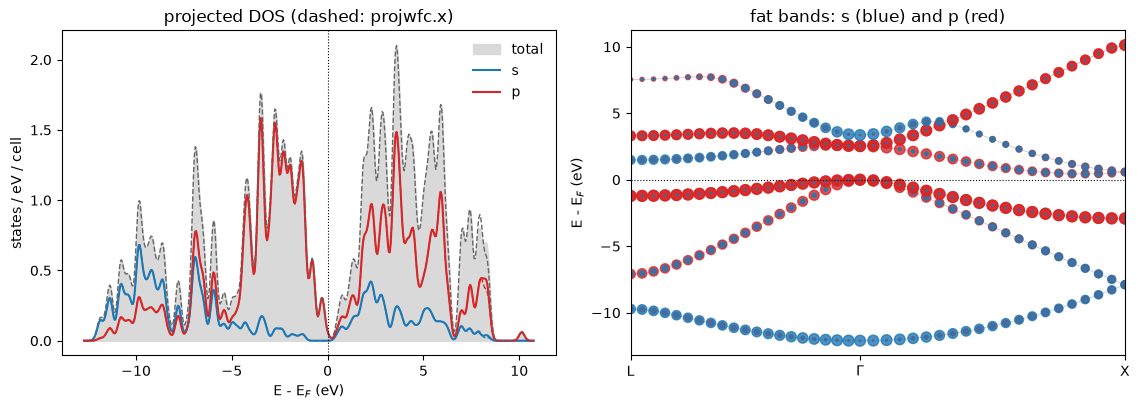

In [5]:
band_path = KPoints.band_path(
    [(0.5, 0.5, 0.5), (0.0, 0.0, 0.0), (1.0, 0.0, 0.0)], [20, 20, 0],
    system.cell, crystal=False,
)
calculation, _, band_energies, band_states = fixed_density_states(
    system, pseudos, scf.density, kpoints=band_path, nbnd=8,
)
band_projections = atomic_projections(calculation, band_states)[0]  # (nk, nproj, nbnd)

s_weight = band_projections[:, [c.index for c in pdos.channels if c.l == 0]].sum(axis=1)
p_weight = band_projections[:, [c.index for c in pdos.channels if c.l == 1]].sum(axis=1)

figure, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2))

qe_total = read_pdos_file(CASES / "reference.si2-us-dense.pdos_tot")[1][0]
qe_s = sum(read_pdos_file(CASES / f"reference.si2-us-dense.pdos_atm#{a}(Si)_wfc#1(s)")[1][0]
           for a in (1, 2))
qe_p = sum(read_pdos_file(CASES / f"reference.si2-us-dense.pdos_atm#{a}(Si)_wfc#2(p)")[1][0]
           for a in (1, 2))
n = energies_ev.size
fermi = scf.homo * RY_TO_EV

left.fill_between(pdos.energies_ev[:n] - fermi, pdos.total.dos[:n] / RY_TO_EV,
                  color="0.85", label="total")
left.plot(pdos.energies_ev[:n] - fermi, pdos.select(l="s")[:n] / RY_TO_EV, color="C0", label="s")
left.plot(pdos.energies_ev[:n] - fermi, pdos.select(l="p")[:n] / RY_TO_EV, color="C3", label="p")
for curve, colour in ((qe_total, "0.4"), (qe_s, "C0"), (qe_p, "C3")):
    left.plot(energies_ev - fermi, curve, ls="--", lw=1.0, color=colour)
left.axvline(0.0, color="k", lw=0.8, ls=":")
left.set_xlabel("E - E$_F$ (eV)"); left.set_ylabel("states / eV / cell")
left.set_title("projected DOS (dashed: projwfc.x)"); left.legend(frameon=False)

x = band_path.path_length
for band in range(band_energies.shape[-1]):
    energy = band_energies[0, :, band] * RY_TO_EV - fermi
    right.scatter(x, energy, s=60 * p_weight[:, band] + 1, color="C3", alpha=0.8)
    right.scatter(x, energy, s=60 * s_weight[:, band] + 1, color="C0", alpha=0.8)
    right.plot(x, energy, color="0.8", lw=0.6, zorder=0)
right.axhline(0.0, color="k", lw=0.8, ls=":")
right.set_xticks([x[0], x[20], x[-1]]); right.set_xticklabels(["L", "$\\Gamma$", "X"])
right.set_ylabel("E - E$_F$ (eV)"); right.set_title("fat bands: s (blue) and p (red)")
right.set_xlim(x[0], x[-1])
figure.tight_layout()

The `s` weight collapses onto the lowest valence band and the `p` weight onto the upper three,
degenerate at Γ — which is the textbook picture of an `sp3` semiconductor, read off the
projections rather than asserted.

---

`PLAN.md` P8 (the *projwfc* sub-entry) has the phase's numbers and its transcription traps —
including the one that matters most here, that `do_projwfc` silently runs the **linear**
tetrahedron method for a projected density of states even when the SCF used Bloechl's.
`tests/regression/test_pdos.py` compares seven cases against `projwfc.x`, and
`tests/unit/test_projwfc.py` holds the checks that need no reference.